<a href="https://colab.research.google.com/github/ChandanGurjar/Exploratory-Data-Analysis-EDA-ML-Models/blob/main/Regression-Projects/Intro_to_Linear_Regression_Medical_Costs_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas-profiling --quiet

# for gettting the data from the link

medical_charges_url='https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'
# we use urllib
from urllib.request import urlretrieve
urlretrieve(medical_charges_url,'medical.csv')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.9/357.9 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 13.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.3/293.3 kB 12.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 16.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 36.4 MB/s eta 0:00:00


('medical.csv', <http.client.HTTPMessage at 0x7d58f4234af0>)

In [ ]:
import pandas as pd

medical_df=pd.read_csv('medical.csv')
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
# for finding the data types of each column we used info() function
medical_df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# statistics for the numerical columns for describing the values as statstics we use describe() function

medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# the follwing settings will improve the default style and font sizes for our charts
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.figsize']=(10,6)
matplotlib.rcParams['figure.facecolor']='#00000000'


In [ ]:
'''Age is a numeric column. The minimum age in the dataset is 18 and maximum is 64
   thus we can visualize the distribution of age using a histogram with 47 bins
'''
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [ ]:
fig=px.histogram(medical_df,
                 x='age',
                 marginal='box',
                 nbins=47,
                 title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

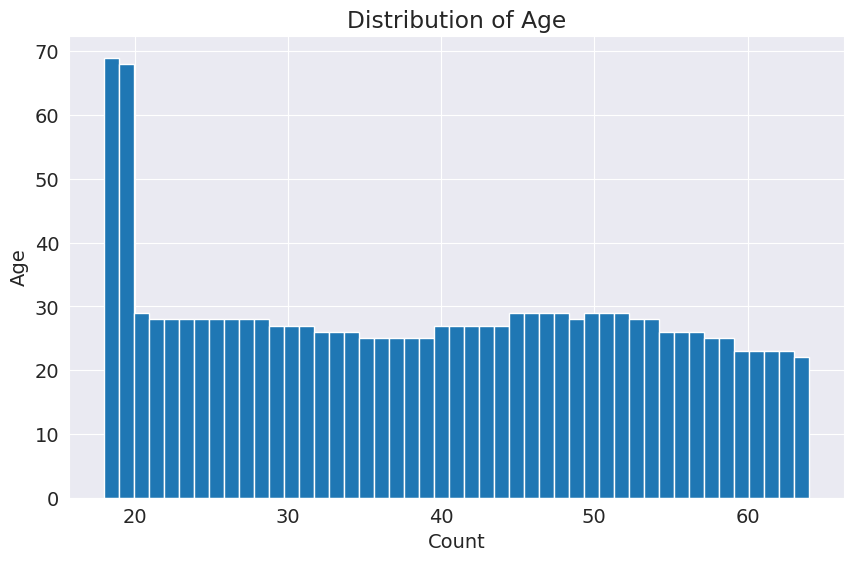

In [ ]:
fig=plt.hist(x='age',bins=47,data=medical_df,)
plt.title("Distribution of Age")
plt.xlabel('Count')
plt.ylabel('Age')
fig;


In [ ]:
fig=px.histogram(medical_df,
                 x='bmi',
                 marginal='box',
                 color_discrete_sequence=['red'],
                 title='Distribution of BMI(Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()


In [ ]:
# let's visualize the distribution of "charges" i.e. the annual medical charges for customers
# this is the column we're trying to predict. let's also use the categorical column

# Charges
fig=px.histogram(medical_df,
                 x='charges',
                 marginal='box',
                 color='smoker',
                color_discrete_sequence=['green','grey'],
                 title='Annual Medical charges')

fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
fig=px.histogram(medical_df,
                 x='charges',
                 marginal='box',
                 color='sex',
                  color_discrete_sequence=['green','grey'],
                 title="Annual Medical Charges with sex")

fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
medical_df.smoker.value_counts()  # for counting the total values

no     1064
yes     274
Name: smoker, dtype: int64

In [ ]:
px.histogram(medical_df,x='smoker',color='sex',title='Smoker')

In [ ]:
# age and charges
'''visualising the relationship between 'age' and 'charges' using a scatter plot.
   Each point in the scatter plot represents one customer.

'''
fig=px.scatter(medical_df,
               x='age',
               y='charges',
               color='smoker',
               opacity=0.8,
               hover_data=['sex'],
               title="Age vs. Charges")
fig.update_traces(marker_size=5)
fig.update_layout(legend_itemclick='toggle')
fig.show()



In [ ]:
# Bmi and charges
''' let's visualize the relationship between BMI(body mass index)
    and charges using another scatter.plot .Once again ,we'll use the values from the
    "smoker" column to color the points
'''
fig=px.scatter(medical_df,
               x='bmi',
               y='charges',
               color='smoker',
               opacity=0.8,
               hover_data=['sex'],
               title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

In [ ]:
# Correlation
''' As you can tell from the analysis the values in some columns are
    more closely related to the values in "charges" compared to other columns
    e.g. 'age' and 'charges' seem to grow together , whereas 'bmi' and 'charges' don't
    this relationship is often expressed numerically using a measure called the correlation
    coefficient ,which can be computed using the .corr method of a Pandas series

'''
medical_df.charges.corr(medical_df.age)


0.2990081933306476

In [ ]:
medical_df.charges.corr(medical_df.bmi)

0.19834096883362895

In [ ]:
'''To compute the correlation for categorical columns ,they must first be
   converted into numeric columns.
'''

smoker_values={'no':0,'yes':1}
smoker_numeric=medical_df.smoker.map(smoker_values)

medical_df.charges.corr(smoker_numeric)

0.787251430498478

In [ ]:
''' the pandas dataframes also provide a .corr method to compute the correlation coefficients
    between all pairs of numeric columns.

'''
medical_df.corr()

<ipython-input-28-806114124fbb>:5: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<ipython-input-29-683a5ed5f299>:4: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



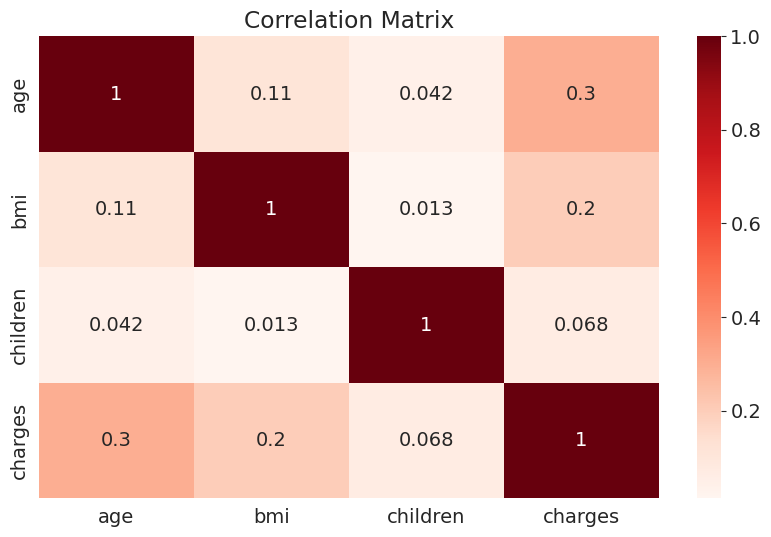

In [ ]:
''' The result of .corr is called a correlation matrix and is
    often visualized using a heatmap
  '''
sns.heatmap(medical_df.corr(),cmap='Reds',annot=True)
plt.title('Correlation Matrix');


In [ ]:
''' we now know that the smoker and age columns have the strongest correlation
    with charges let's try to find a way of estimating the value of charges using the value of age
    for non-smokers .First let's create datafram containing just the data for non-smokers.
 '''
non_smokers_df=medical_df[medical_df.smoker=='no']
non_smokers_df

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350


In [ ]:
smokers_df=medical_df[medical_df.smoker=='yes']
smokers_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
11,62,female,26.290,0,yes,southeast,27808.72510
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
...,...,...,...,...,...,...,...
1313,19,female,34.700,2,yes,southwest,36397.57600
1314,30,female,23.655,3,yes,northwest,18765.87545
1321,62,male,26.695,0,yes,northeast,28101.33305
1323,42,female,40.370,2,yes,southeast,43896.37630


In [ ]:

fig=px.scatter(non_smokers_df,x='age',y='charges',title='Age vs Charges',color='sex',opacity=0.8)
fig.update_traces(marker_size=8)
fig.show()








Enter the value of slope: 220
Enter the value of intercept-1200


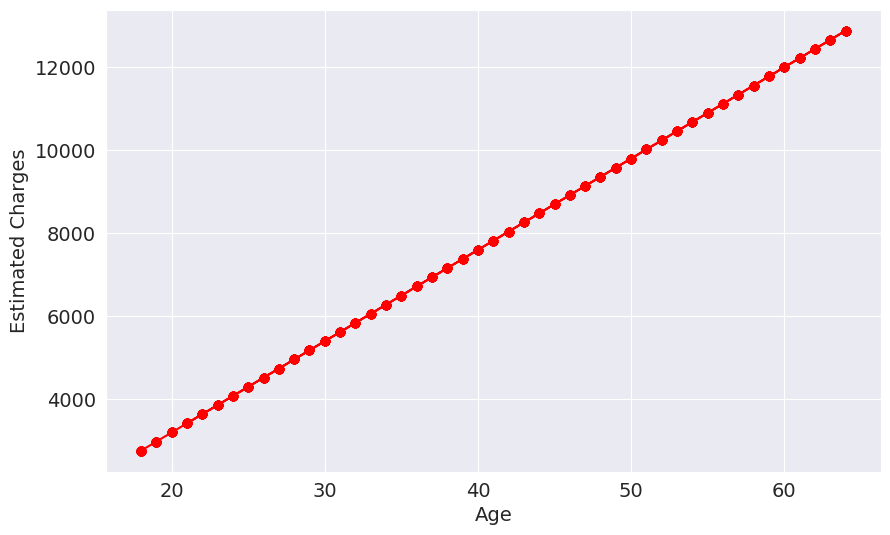

In [ ]:
''' Apart from a few exceptions .the points seem to form a line ,we"ll try and fit a line using
    this points ,and use the line to predict charges for a given age.
     A line on the X and Y coordinates has the following formula:
     y=mx+b
     The line is characterizes two numbers: w(called"slope") and b(called"intercept").
'''

# MODEL
''' In the above case ,the x axis shows"age and the yaxis shows charges .Thus
    we're assuming the following between the two:
    charges=w*age+b

    We"ll try determine w and b for the liine that best fits the data.
    ** This technique is called is a linear regression, and we call the above equation a linear regression model,
       because it models the relationship between age and charges as straight line.
    ** The numbers w and b are called the parameters or weights of the model
    ** The valuees in the age column of the dataset are called the inputs to the model
       and the values in the charges column are called targest".

'''
def estimate_charges(age,w,b):
  return w*age+b
ages=non_smokers_df.age

x=int(input('Enter the value of slope: '))
y=int(input('Enter the value of intercept'))
estimated_charges=estimate_charges(ages,x,y)

plt.plot(ages,estimated_charges,'r-o');
plt.xlabel('Age')
plt.ylabel('Estimated Charges');


In [ ]:


def estimate_charges1(age,w,b):
  return w*age+b

ages1=smokers_df.age

x=int(input('Enter the value of slope: '))
y=int(input('Enter the value of intercept'))
estimated_charges1=estimate_charges1(ages1,x,y)



Enter the value of slope: 220
Enter the value of intercept-1200


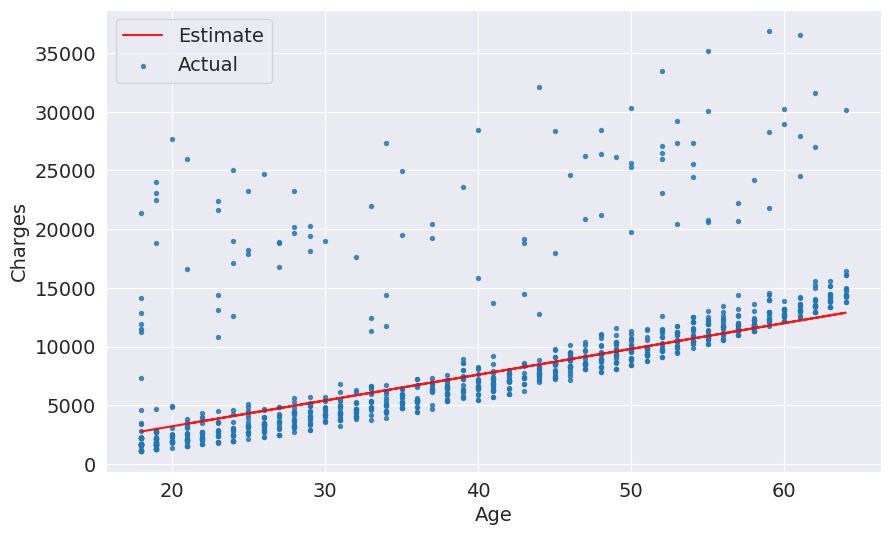

In [ ]:
# As expected ,the points lie on a straight line.
# we can overlay this line on the actual data,so see how well our model fits the data

target=non_smokers_df.charges
plt.plot(ages,estimated_charges,'r',alpha=0.9);
plt.scatter(ages,target,s=8,alpha=0.8)
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(['Estimate','Actual'])




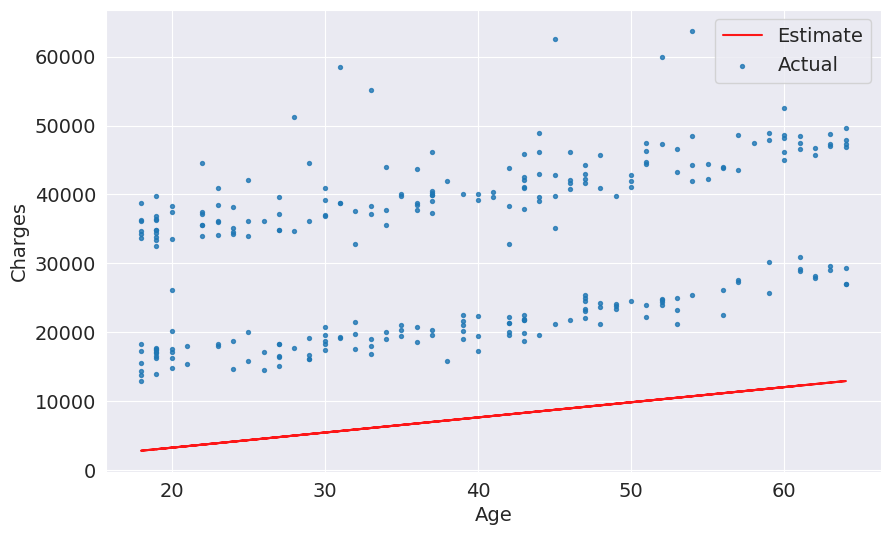

In [ ]:
target1=smokers_df.charges
plt.plot(ages1,estimated_charges1,'r',alpha=0.9);
plt.scatter(ages1,target1,s=8,alpha=0.8)
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(['Estimate','Actual'])

Enter the slope? 220
Enter the intecept? -1200


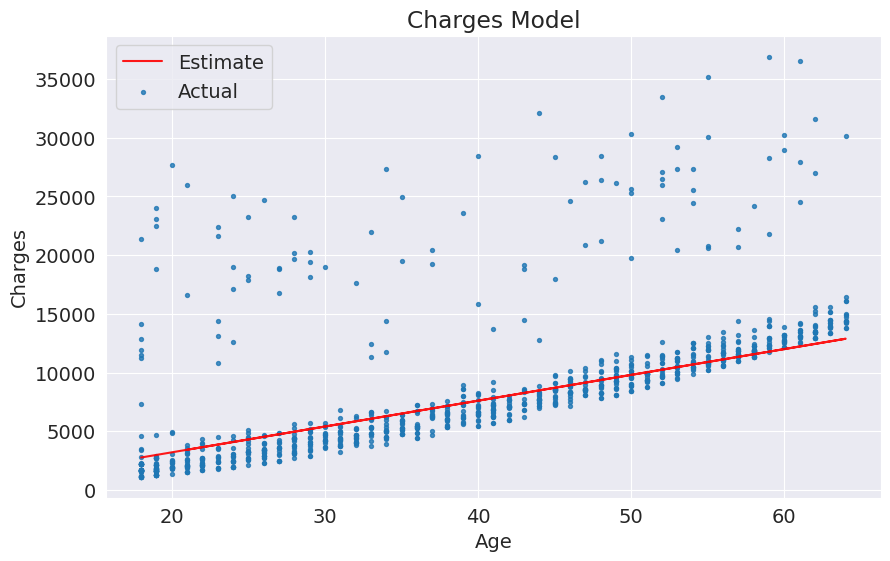

In [ ]:
''' Clearly ,the our estimates are quite poor and the line does not fit data
    However we can try different values of w and b to move the line around.let's define
    a helper function try_parameters which takes w and b as inputs and creates the above plot.


'''

def try_parameters(w,b):
  ages=non_smokers_df.age
  target=non_smokers_df.charges
  estimated_charges=estimate_charges(ages,w,b)
  plt.plot(ages,estimated_charges,'r',alpha=0.9);
  plt.scatter(ages,target,s=8,alpha=0.8);
  plt.xlabel("Age")
  plt.ylabel("Charges")
  plt.title("Charges Model")
  plt.legend(['Estimate','Actual'])


x=int(input("Enter the slope? "))
y=int(input("Enter the intecept? "))
try_parameters(x,y)


Enter the slope? 450
Enter the intecept? 1400


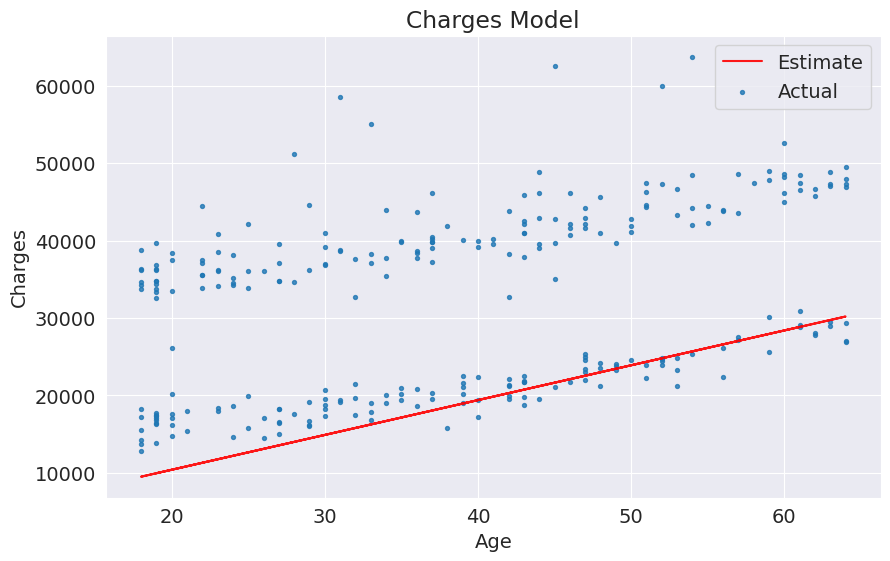

In [ ]:
def try_parameters1(w,b):
  ages1=smokers_df.age
  target1=smokers_df.charges
  predictions1=estimate_charges1(ages1,w,b)
  plt.plot(ages1,predictions1,'r',alpha=0.9);
  plt.scatter(ages1,target1,s=8,alpha=0.8);
  plt.xlabel("Age")
  plt.ylabel("Charges")
  plt.title("Charges Model")
  plt.legend(['Estimate','Actual'])


x=int(input("Enter the slope? "))
y=int(input("Enter the intecept? "))
try_parameters1(x,y)

RMSE loss:  4686.97290587829


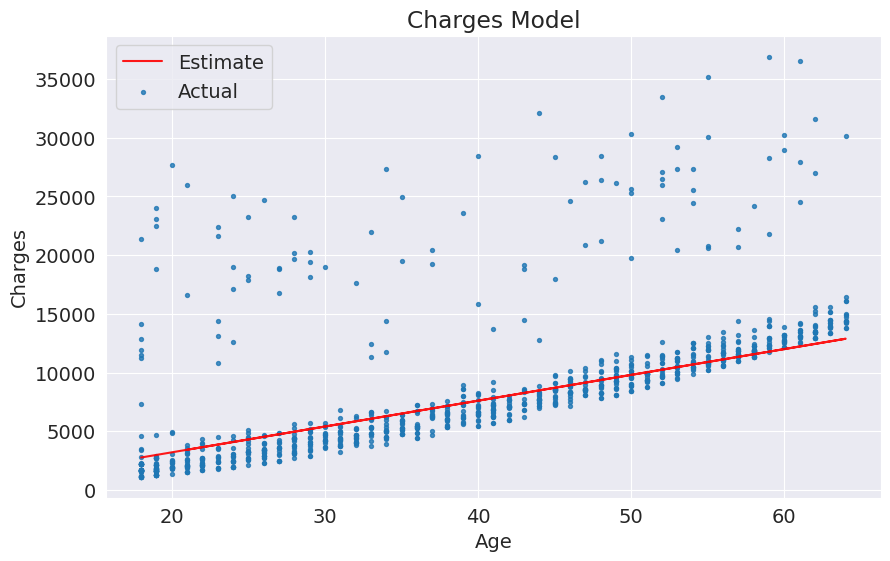

In [ ]:
# let's define a function to compute the Rmse.

import numpy as np
def rmse(targets,predictions):
  return np.sqrt(np.mean(np.square(targets-predictions)))

w=250
b=-1000

try_parameters(w,b)




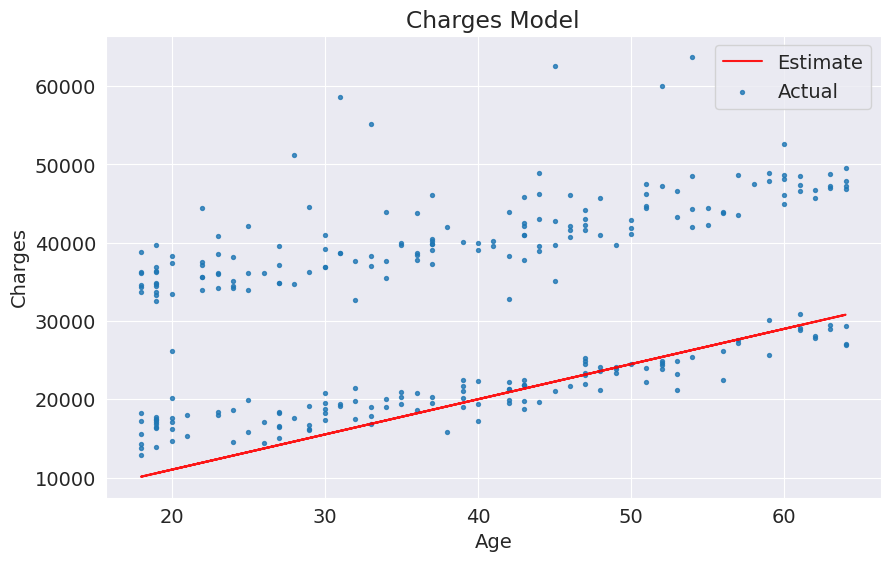

In [ ]:
# let's define a function to compute the Rmse.

import numpy as np
def rmse(targets,predictions):
  return np.sqrt(np.mean(np.square(targets-predictions)))

w=450
b=2000

try_parameters1(w,b)


In [ ]:
targets=non_smokers_df['charges']
predicted=estimate_charges(non_smokers_df.age,w,b)
rmse(targets,predicted)

12482.047609715835

In [ ]:
# let's define a function to compute the Rmse.

import numpy as np
def rmse(targets,predictions):
  return np.sqrt(np.mean(np.square(targets-predictions)))



In [ ]:
targets1=smokers_df['charges']
predicted=estimate_charges1(smokers_df.age,w,b)
rmse(targets1,predicted)

16749.256657880593

RMSE loss:  4669.651885507871


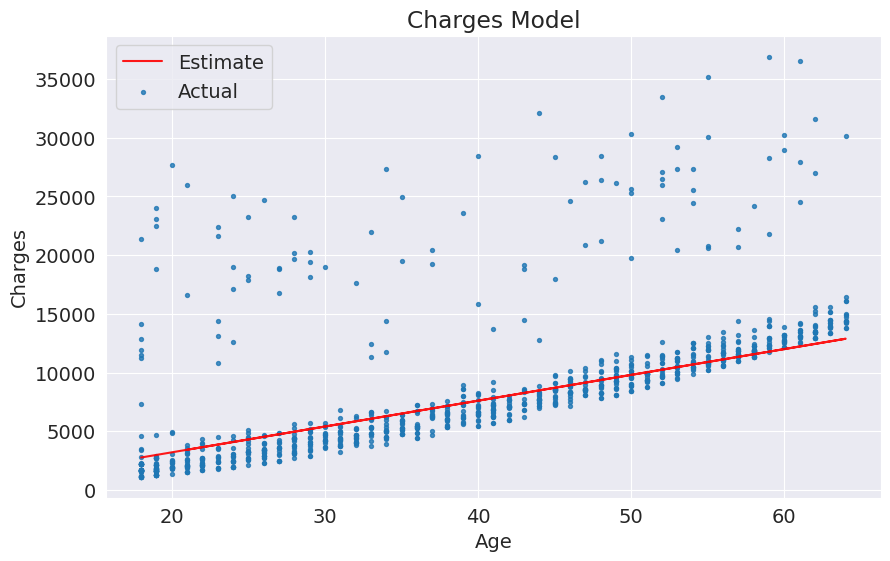

In [ ]:
def try_parameters(w,b):
  ages=non_smokers_df.age
  target=non_smokers_df.charges
  predictions=estimate_charges(ages,w,b)
  plt.plot(ages,estimated_charges,'r',alpha=0.9);
  plt.scatter(ages,target,s=8,alpha=0.8);
  plt.xlabel("Age")
  plt.ylabel("Charges")
  plt.title("Charges Model")
  plt.legend(['Estimate','Actual']);
  loss=rmse(target,predictions)
  print("RMSE loss: ", loss)


try_parameters(250,-1500)

In [ ]:
# Optimizer
''' Next we need a strategy to modify weights w and b to reduce the loss and
    improve the fit of the line to the data.

'''

# Linear Regression using Scikit-learn
''' In pracitce you"ll never need to implement either of the above method yourself
   You can use a library like scikit-learn to do this for you
'''

# pip install scikit-learn --quiet
'''   let's use the LinearRegessin class from scikit-learn to find the best fit line for "age vs Charges
      using the ordinary least squares optimization technique

'''

from sklearn.linear_model import LinearRegression
# first we create a new model object.
model=LinearRegression()


''' Next we can use the fit method of the model to find the best fit line for the inputs and
    target .
'''

help(model.fit)

# help on method fit in module sklearn.linear_model._base:



Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.
    
    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.
    
    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.
    
    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.
    
        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.
    
    Returns
    -------
    self : object
        Fitted Estimator.



In [ ]:
inputs=non_smokers_df[['age']]
targets=non_smokers_df.charges
print('input.shape: ',inputs.shape)
print('target.shape:', targets.shape)


input.shape:  (1064, 1)
target.shape: (1064,)


In [ ]:
model.fit(inputs,targets)




LinearRegression()

In [ ]:
'''  We can now make predictins using the model.let's try predicting the charges
    for the ages 23,37,61
'''

model.predict(np.array([[23],[37],[61]]))


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [ ]:
''' Do these values seem reasonable? compare them with the scatter plot above.
    let compute the predictions for the entire set of inputs
'''
predictions= model.predict(inputs)
predictions


array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [ ]:
# let's compute the RMSE loss to evaluate the model.
lrmse=rmse(targets,predictions)
print(lrmse)

''' Seems like our prediction is off by $4000 on average which is not too
    bad considering the fact that there are several outliers

'''




6041.6796511744515


' Seems like our prediction is off by $4000 on average which is not too\n    bad considering the fact that there are several outliers\n\n'

In [ ]:
# The parameters of the model are stored in the coef_ and intercept_ properties
# w
model.coef_



array([267.24891283])

In [ ]:
# b
model.intercept_

-2091.4205565650864

RMSE loss:  4662.516524487403


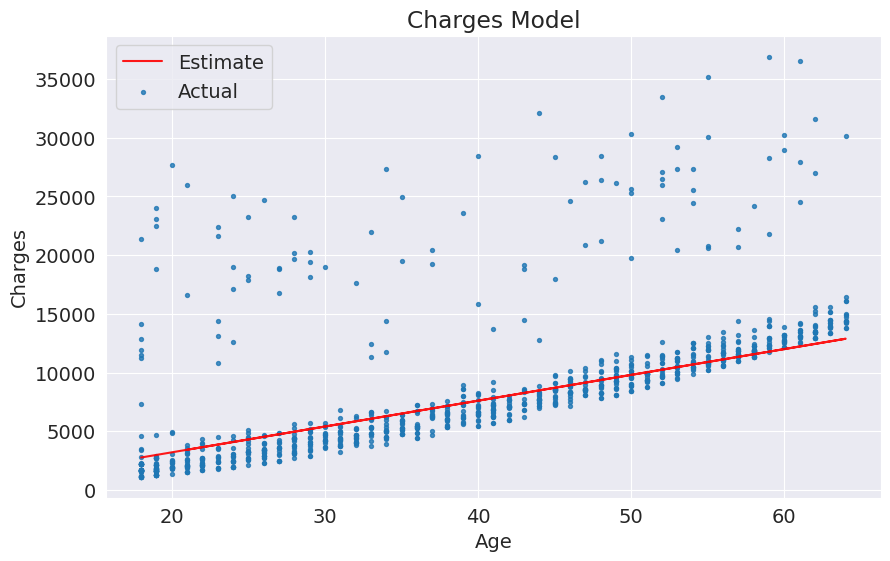

In [ ]:
# are these parameters close to your best guesses?
# let's visualize the line created by the above parameters .

try_parameters(267,-2091)



In [ ]:

# create inputs and targets
inputs,targets=non_smokers_df[['age']],non_smokers_df['charges']

# create and train the model
model=LinearRegression().fit(inputs,targets)

# Generate predictions
predictions=model.predict(inputs)
# Compute loss to evalute the model

loss=rmse(targets,predictions)
print('Loss: ',loss)


Loss:  4662.505766636395


loss: 10711.00334810241


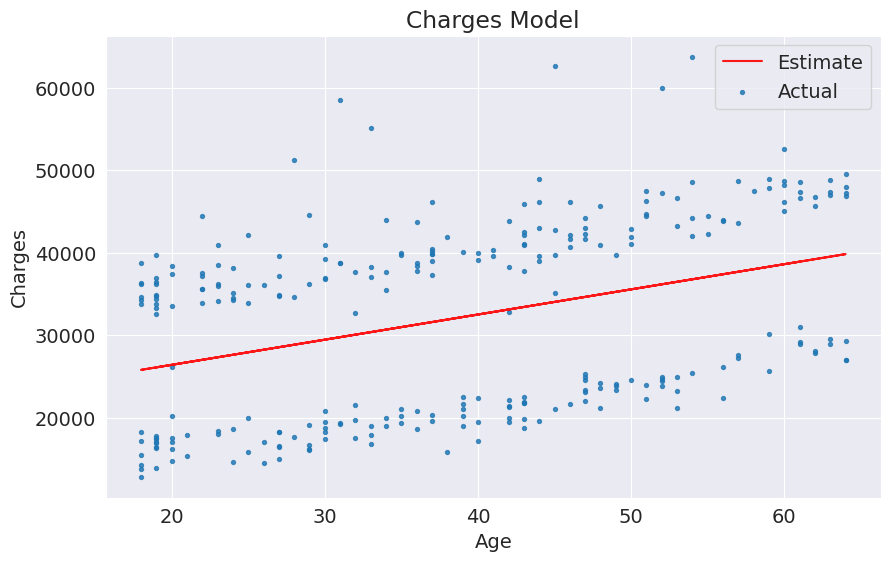

In [ ]:
inputs,targets=smokers_df[['age']],smokers_df['charges']

# create and train the model
model1=LinearRegression().fit(inputs,targets)
prediction=model1.predict(inputs)



try_parameters1(model1.coef_,model1.intercept_)

# compute loss to evalute the model
loss=rmse(targets,prediction)
print('loss:', loss)




In [ ]:
model1.coef_

array([305.23760211])

In [ ]:
model1.intercept_


20294.128126915966

In [ ]:
# liner regression using multiple features
''' so far,we've used on the 'age' feature to estimate 'charges'
    Adding another feature like 'bmi' is fairly straightforward.
    we simply assume the following relationship
    charges=w1*age+w2*bmi+b

'''
# we need to change just one line of code to include the bmi

# create the inputs and targets

inputs,targets=non_smokers_df[['age','bmi']],non_smokers_df['charges']

# create and train the model
model=LinearRegression().fit(inputs,targets)

# generate predictions
predictions=model.predict(inputs)
# compute the loss to evalute the model

loss=rmse(targets,predictions)
print('loss:', loss)

loss: 4662.3128354612945


In [ ]:
inputs,targets=smokers_df[['age','bmi']],smokers_df['charges']

model1=LinearRegression().fit(inputs,targets)
predictions=model1.predict(inputs)



loss=rmse(targets,predictions)
print('loss: ',loss)

loss:  5722.782238884455


In [ ]:
model1.coef_


array([ 266.29222371, 1438.09098289])

In [ ]:
model.intercept_


-2293.6320906488727

In [ ]:
''' As you can see, adding the BMI doesn't seem to reduce the loss by much
    as the bmi has a very weak correlation with charges especially for non smokers
'''
non_smokers_df.charges.corr(non_smokers_df.bmi)


0.0840365431283327

In [ ]:
fig=px.scatter(non_smokers_df,x='bmi',y='charges',
               title="BMI vs Charges",)
fig.update_traces(marker_size=5)
fig.show()


In [ ]:
''' We can also visualize the relationship between all varibles 'age' and 'bmi
    using a 3d scatter plot.
'''

fig=px.scatter_3d(non_smokers_df,x='age',y='bmi',z='charges')
fig.update_traces(marker_size=5,marker_opacity=0.5)
fig.show()

''' As you can see that it's harder to interpret a 3d scatter plot compared to 2d scatter plot
    As we add more features, it becomes impossible to visualize all features at once ,
     which is why we use measures  like correlation and loss

'''
model.coef_ ,model.intercept_

(array([266.87657817,   7.07547666]), -2293.6320906488727)

In [ ]:
''' Let's go one step further ,and add the final numeric column:"Chidren"
    Which seems to have some correlation with 'charges'.
    charges=w1*age+w2*bmi+w3*childern+b
'''
non_smokers_df.charges.corr(non_smokers_df.children)

0.13892870453542192

In [ ]:
fig=px.strip(non_smokers_df,x='children',y='charges',title="Children vs. Charges")
fig.update_traces(marker_size=4,marker_opacity=0.7)
fig.show()

In [ ]:
fig=px.scatter(non_smokers_df,x='children',y='charges',title="Children vs. Charges")
fig.update_traces(marker_size=4,marker_opacity=0.7)
fig.show()


In [ ]:
# Create inputs and targets
inputs,targets=non_smokers_df[['age','bmi','children']],non_smokers_df['charges']
# Create and train the model
model=LinearRegression().fit(inputs,targets)

# generate the predictions
predictions=model.predict(inputs)

# compute the loss to evalute the model
loss=rmse(targets,predictions)
print('loss: ',loss)

''' Once again we don't see a big reduction in the loss ,even though it's greater
    than in the case of bmi


'''


loss:  4608.470405038247


" Once again we don't see a big reduction in the loss ,even though it's greater\n    than in the case of bmi\n\n\n"

In [ ]:
# for the smokers
inputs,targets=smokers_df[['age','bmi','children']],smokers_df['charges']
model1=LinearRegression().fit(inputs,targets)
predictions=model1.predict(inputs)
loss=rmse(targets,predictions)
print('loss: ',loss)

loss:  5718.202480524154


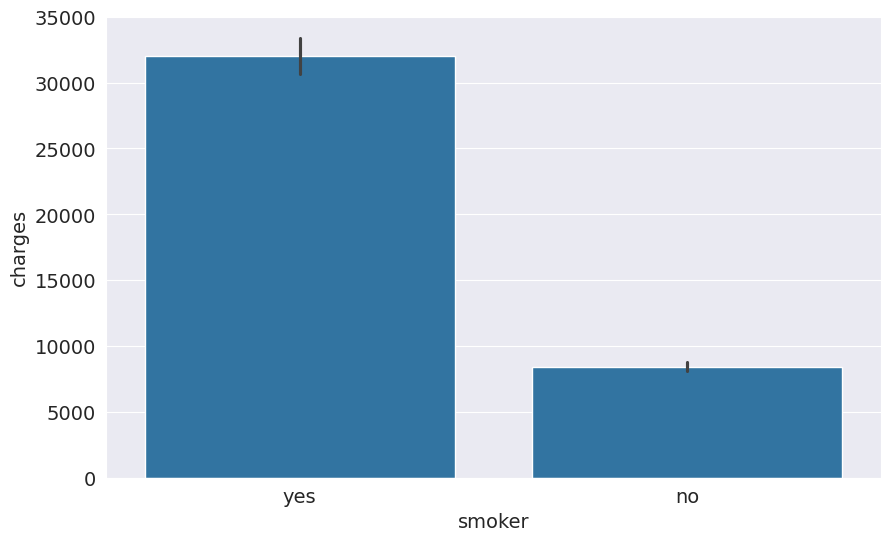

In [ ]:
# Using Categorical Features For Machine Learning

# Binary Categories

''' The 'smoker' category had just two values 'yes' and 'no'. let's create a new column
     'smoker_code' containing 0 for "no" and 1 for "yes"


'''

sns.barplot(data=medical_df,x='smoker',y='charges');

In [ ]:
fig=px.bar(medical_df,x='smoker',y='charges')
fig.show()

In [ ]:
smoker_codes={'no':0,'yes':1}
# We are making a new column with name smoker_code
medical_df['smoker_code']=medical_df.smoker.map(smoker_codes)


In [ ]:
medical_df.charges.corr(medical_df.smoker_code)

0.787251430498478

In [ ]:
medical_df


,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


In [ ]:
# WE can now use the smoker_df column for linear Regression .
# charges=w1*age+w2*bmi+w3*children+w4*smoker+b

# create inputs and targets

inputs,targets=medical_df[['age','bmi','children']],medical_df['charges']

# Create and train the model
model=LinearRegression().fit(inputs,targets)

# Generate the predictions
predictions=model.predict(inputs)

# compute the loss to evalute the model
loss =rmse(targets,predictions)
print('loss: ',loss)

loss:  11355.317901125973


In [ ]:
# WE can now use the smoker_df column for linear Regression .
# charges=w1*age+w2*bmi+w3*children+w4*smoker+b

# create inputs and targets

inputs,targets=medical_df[['age','bmi','children','smoker_code']],medical_df['charges']

# Create and train the model
model=LinearRegression().fit(inputs,targets)

# Generate the predictions
predictions=model.predict(inputs)

# compute the loss to evalute the model
loss =rmse(targets,predictions)
print('loss: ',loss)

''' The loss reduces from 11355 to 6056 ,almost by 50%  This is an important lesson :
    Never ignore the categorical data
  '''

loss:  6056.439217188081


' The loss reduces from 11355 to 6056 ,almost by 50%  This is an important lesson :\n    Never ignore the categorical data\n  '

<Axes: xlabel='sex', ylabel='charges'>

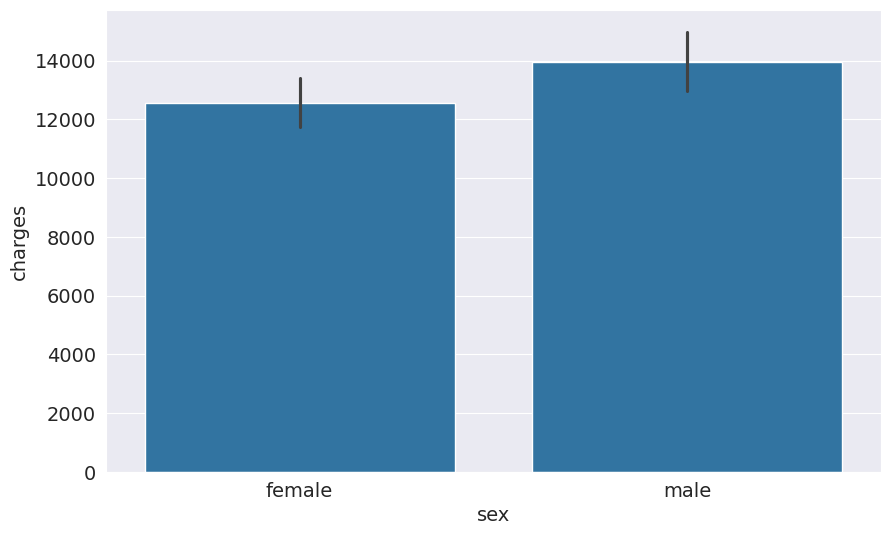

In [ ]:
# let's try adding the sex column  as well.
# charges=w1*age+w2*bmi+w3*children+w4*smoker+w5*sex+b

sns.barplot(data=medical_df,x='sex',y='charges')


In [ ]:
sex_codes={'female':0,'male':1}
medical_df['sex_code']=medical_df.sex.map(sex_codes)


In [ ]:
medical_df.charges.corr(medical_df.sex_code)


0.057292062202025484

In [ ]:
# Create inputs and targets

inputs,targets=medical_df[['age','bmi','children','smoker_code','sex_code']],medical_df['charges']
# create and train the model

model=LinearRegression().fit(inputs,targets)

# predict

predictions=model.predict(inputs)

# loss calculation

loss=rmse(targets,predictions)
print('loss: ',loss)

# As you might expect, this does have a significant impact on the loss .

loss:  6056.100708754546


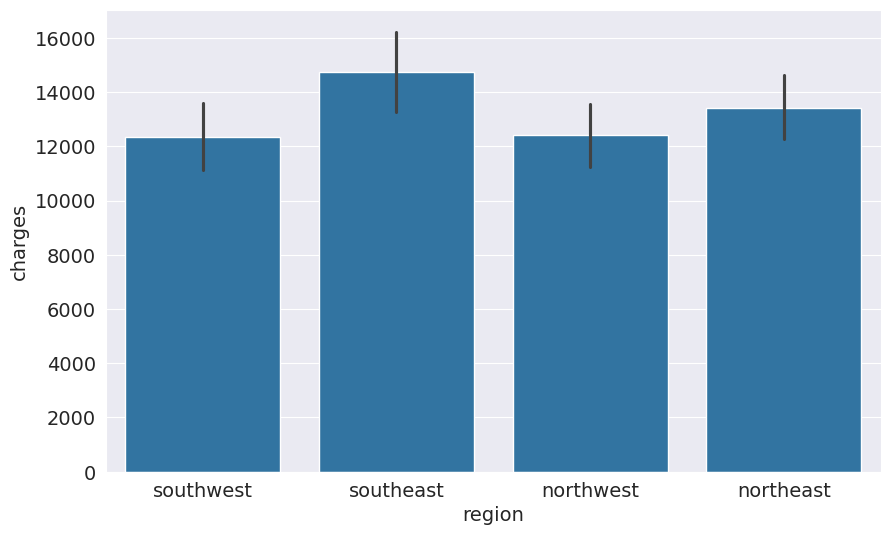

In [ ]:
# One-Hot Encoding
''' The 'region' column contains 4 values ,so we'll need to use hot
    encoding and create a new column for each region .
'''
sns.barplot(data=medical_df,x='region',y='charges');


In [ ]:
from sklearn import preprocessing
enc=preprocessing .OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_



[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [ ]:
one_hot=enc.transform(medical_df[['region']]).toarray()
one_hot


array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [ ]:
medical_df[['northeast','northwest','southeast','southwest']]=one_hot



In [ ]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [ ]:
''' let's include the region columns into our linear regression model.
    charges=w1*age+w2*bmi+w3*children+w4*smoker+w5*sex+w6*region+b
'''

# Create inputs and targets
inputs_cols=['age','bmi','children','smoker_code','sex_code','northeast','northwest','southeast','southwest']
inputs,targets=medical_df[inputs_cols], medical_df['charges']

# Create and train the model
model =LinearRegression().fit(inputs,targets)

# Generate predictions
predictions =model.predict(inputs)

# Compute loss to evalutethe model
loss=rmse(targets,predictions)
print('loss: ',loss)

# Once again ,this leads to a fairly small reduction in the loss


loss:  6041.6796511744515


In [ ]:
model.coef_

array([  256.85635254,   339.19345361,   475.50054515, 23848.53454191,
        -131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
        -373.04175627])

In [ ]:
model.intercept_

-12525.547811195444

In [ ]:
''' Here we are making a datafram adding the feature and weight column '''

weights_df=pd.DataFrame({
    'feature':np.append(inputs_cols,1),
    'weight': np.append(model.coef_,model.intercept_)
})
weights_df

''' while it seems like bmi and the northeast have a higher weight than age
    keep that in mind that the range of values for bmi is limited(15to40) and the
    'northeas' column only takes the values 0 and 1.

    Because different columns have different ranges ,we run into two issues .
    1. we can't compare the weights of differernt column to identify which features are important
    2.A column with a larger range of inputs may disproportionately affect the loss and dominate the optimization process

    for this reason, it's common practice to scale(or standardize ) the values in numeric column
    by substracting the mean and dividing by the standard deviation
'''


" while it seems like bmi and the northeast have a higher weight than age\n    keep that in mind that the range of values for bmi is limited(15to40) and the\n    'northeas' column only takes the values 0 and 1.\n\n    Because different columns have different ranges ,we run into two issues .\n    1. we can't compare the weights of differernt column to identify which features are important\n    2.A column with a larger range of inputs may disproportionately affect the loss and dominate the optimization process\n\n    for this reason, it's common practice to scale(or standardize ) the values in numeric column\n    by substracting the mean and dividing by the standard deviation\n"

In [ ]:
#we can apply scalling using the  'StandardScaler' class from scikit-learn

medical_df


,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [ ]:
from sklearn.preprocessing import StandardScaler
numeric_cols=['age','bmi','children']
scaler=StandardScaler()
scaler.fit(medical_df[numeric_cols])

StandardScaler()

In [ ]:
# mean
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [ ]:
# variance
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

In [ ]:
scaled_inputs=scaler.transform(medical_df[numeric_cols])
scaled_inputs


array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

In [ ]:
# these can now we can combined with the categorical data
cat_cols=['smoker_code','sex_code','northeast','northwest','southeast','southwest']
categorical_data=medical_df[cat_cols].values

In [ ]:
inputs=np.concatenate((scaled_inputs,categorical_data),axis=1)
targets=medical_df.charges


In [ ]:
# Create and train the model
model=LinearRegression().fit(inputs,targets)

# Generate predictions
predictions=model.predict(inputs)

# compute loss to evalute the model

loss=rmse(targets,predictions)
print('loss: ',loss)


loss:  6041.6796511744515


In [ ]:
''' We can now compare the weights in the formula :

'''
weights_df=pd.DataFrame({
    'feature':np.append(numeric_cols+cat_cols,1),
    'weights':np.append(model.coef_,model.intercept_)
})
weights_df.sort_values('weights',ascending=False)

''' As you can see now the most important feature are :
   1. age
   2.Smoker
   3.BMI
'''


' As you can see now the most important feature are :\n   1. age\n   2.Smoker\n   3.BMI\n'

In [ ]:
# Creating a test Set
''' Models like the one we've created in this tutorial are designed to be used in the real world
    it's common practice to set aside a small fraction of the data(e.g.10%)
    just for testing and reporting the results of the model.

'''

from sklearn.model_selection import train_test_split

inputs_train,inputs_test, targets_train,targets_test=train_test_split(inputs,targets,test_size=0.1)


In [ ]:
# Create and train the model
model=LinearRegression().fit(inputs_train,targets_train)

# Generate  prrdictions

predictions_test=model.predict(inputs_test)

# compute the loss to evalute the model
loss=rmse(targets_test,predictions_test)
print(' Test loss: ',loss)


 Test loss:  6006.865627744248


In [ ]:
# let's compare with the training loss

# Generate the predictions
predictions_train=model.predict(inputs_train)

loss=rmse(targets_train,predictions_train)
print("Training loss: ", loss)

Training loss:  6048.726064742883
